In [2]:
import pandas as pd
import seaborn as sns

## Clean duplicate functions and docstrings

In [3]:
all_data = pd.read_csv('data/Menagerie/data/docstring_code_grades.csv', index_col=0)
all_data = all_data[~all_data['docstring_summary'].isna()]
all_data['grade'] = pd.Categorical(all_data['grade'],
                                   ['A++', 'A+', 'A', 'A-',
                                    'B+', 'B', 'B-',
                                    'C+', 'C', 'C-',
                                    'D+', 'D', 'D-',
                                    'F'])
# all_data['grade'] = all_data['grade'].apply(lambda x: x[0])

grey = (187/255, 187/255, 187/255)
darkgreen = (51/255, 117/255, 56/255)
teal = (93/255, 168/255, 153/255)
blue = (148/255, 203/255, 236/255)
yellow = (220/255, 205/255, 125/255)
red = (168/255, 96/255, 93/255)
pale_yellow = (164/255, 168/255, 93/255)

color_palette = sns.color_palette([grey, darkgreen, teal, blue, yellow, red, pale_yellow])

menagerie_grades = ['A++', 'A+', 'A', 'A-', 'B+', 'B', 'B-','C+', 'C', 'C-', 'D+', 'D', 'D-', 'F']
menagerie_truncated_grades = ['A', 'B', 'C', 'D', 'F']

In [4]:
print(all_data.shape)
all_data.head()

(28354, 10)


,assignment_number,grade_code,grade,path,docstring,docstring_summary,docstring_tokens,function,function_tokens,line_numbers
0,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,This is what the rabbit does most of the time ...,This is what the rabbit does most of the time ...,"['This', 'is', 'what', 'the', 'rabbit', 'does'...",public void act(List<Animal> newRabbits)\n ...,"['public', 'void', 'act', '(', 'List', '<', 'A...",L60-L81
1,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Increase the age.\nThis could result in the ra...,Increase the age.\nThis could result in the ra...,"['Increase', 'the', 'age', '.', 'This', 'could...",private void incrementAge()\n {\n ag...,"['private', 'void', 'incrementAge', '(', ')', ...",L88-L97
2,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Make this rabbit more hungry. This could resul...,Make this rabbit more hungry. This could resul...,"['Make', 'this', 'rabbit', 'more', 'hungry', '...",private void incrementHunger()\n {\n ...,"['private', 'void', 'incrementHunger', '(', ')...",L102-L108
3,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Look for rabbits adjacent to the current locat...,Look for rabbits adjacent to the current locat...,"['Look', 'for', 'rabbits', 'adjacent', 'to', '...",private Location findFood()\n {\n Fi...,"['private', 'Location', 'findFood', '(', ')', ...",L115-L134
4,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Check whether or not this rabbit is to give bi...,Check whether or not this rabbit is to give bi...,"['Check', 'whether', 'or', 'not', 'this', 'rab...",private void giveBirth(List<Animal> newRabbits...,"['private', 'void', 'giveBirth', '(', 'List', ...",L141-L156


In [5]:
all_data['grade'].value_counts()

grade
A      9673
B+     5902
A-     5359
A+     3985
B      1443
B-      869
A++     459
F       260
C       199
D+       52
D        52
D-       52
C+       49
C-        0
Name: count, dtype: int64

In [6]:
def transform_values(row):
    grades = set(list(row['grade']))
    output = {'docstring': list(row['docstring'])[0], 'function': list(row['function'])[0], 'grade': str(grades), 'grade_count': len(grades)}
    return pd.Series(output, index=['docstring', 'function', 'grade', 'grade_count'])

def hash_code_docstring_pairs(row):
    code_ds_pair = row['docstring'] + '\n' + row['function']
    return hash(code_ds_pair)

In [7]:
# Hash generated on tokens to remove whitespace causing unique values
all_data['hash'] = all_data.apply(hash_code_docstring_pairs, axis=1)
duplicate_value_df = all_data[['hash', 'grade', 'docstring', 'function']].groupby(['hash']).apply(transform_values)
duplicate_value_df[duplicate_value_df['grade_count'] > 1].head()

/var/folders/1y/6byzw1px62g2f5w7p_rhb6kh0000gn/T/ipykernel_32491/163026546.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duplicate_value_df = all_data[['hash', 'grade', 'docstring', 'function']].groupby(['hash']).apply(transform_values)


,docstring,function,grade,grade_count
hash,,,,
-9193714620186963012,Make this snake more hungry. This could result...,private void incrementHunger()\n {\n ...,"{'A+', 'A-', 'A', 'B+'}",4
-9192074983552437857,Return the plant's field.\n@return The plant's...,protected Field getField()\n {\n ret...,"{'A', 'B-', 'A+', 'B', 'A-', 'B+'}",6
-9181984158862232934,"Return a string of the form row,column\n@retur...",public String toString()\n {\n retur...,"{'A++', 'A', 'F', 'C', 'D-', 'B-', 'C+', 'A+',...",13
-9159468211560698139,Try to find a free location that is adjacent t...,public Location freeAdjacentLocation(Location ...,"{'A+', 'A'}",2
-9155913385314525429,Check whether the organism is alive or not.\n@...,public boolean isAlive()\n {\n retur...,"{'A+', 'A'}",2


<Axes: xlabel='grade', ylabel='count'>

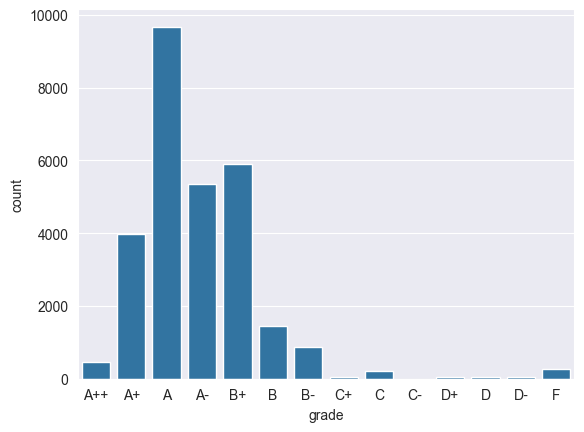

In [8]:
sns.countplot(all_data, x='grade')

### Find Consensus

In [9]:
print(all_data.shape)
all_data.head()

(28354, 11)


,assignment_number,grade_code,grade,path,docstring,docstring_summary,docstring_tokens,function,function_tokens,line_numbers,hash
0,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,This is what the rabbit does most of the time ...,This is what the rabbit does most of the time ...,"['This', 'is', 'what', 'the', 'rabbit', 'does'...",public void act(List<Animal> newRabbits)\n ...,"['public', 'void', 'act', '(', 'List', '<', 'A...",L60-L81,6446017461322236242
1,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Increase the age.\nThis could result in the ra...,Increase the age.\nThis could result in the ra...,"['Increase', 'the', 'age', '.', 'This', 'could...",private void incrementAge()\n {\n ag...,"['private', 'void', 'incrementAge', '(', ')', ...",L88-L97,7163840076824797718
2,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Make this rabbit more hungry. This could resul...,Make this rabbit more hungry. This could resul...,"['Make', 'this', 'rabbit', 'more', 'hungry', '...",private void incrementHunger()\n {\n ...,"['private', 'void', 'incrementHunger', '(', ')...",L102-L108,-3015134700114661646
3,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Look for rabbits adjacent to the current locat...,Look for rabbits adjacent to the current locat...,"['Look', 'for', 'rabbits', 'adjacent', 'to', '...",private Location findFood()\n {\n Fi...,"['private', 'Location', 'findFood', '(', ')', ...",L115-L134,-5943566355722936898
4,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Check whether or not this rabbit is to give bi...,Check whether or not this rabbit is to give bi...,"['Check', 'whether', 'or', 'not', 'this', 'rab...",private void giveBirth(List<Animal> newRabbits...,"['private', 'void', 'giveBirth', '(', 'List', ...",L141-L156,-8720499563198729206


In [10]:
def find_consensus(row):
    grades = list(row['grade'])
    
    grade_dict = {}
    
    for grade in grades:
        if grade not in grade_dict.keys():
            grade_dict[grade] = 1
        else:
            grade_dict[grade] += 1
             
    if len(grade_dict) == 1:
        grade_consensus = list(grade_dict.keys())[0]
    elif all(count == list(grade_dict.values())[0] for count in grade_dict.values()):
        
        grade_consensus = None
    else:
        grade_consensus = max(grade_dict, key=grade_dict.get)
    
    output = {'docstring': list(row['docstring'])[0], 'function': list(row['function'])[0], 'grades': grade_dict, 'grade_count': len(grades), 'grade': grade_consensus}
    return pd.Series(output, index=['docstring', 'function', 'grades', 'grade_count', 'grade'])

In [11]:
unique_consensus_df = all_data.groupby('hash').apply(find_consensus)
unique_consensus_df['grade'] = pd.Categorical(unique_consensus_df['grade'], menagerie_grades, ordered=True)
unique_consensus_df[unique_consensus_df['grade_count'] > 3].head(100)
# unique_consensus_df

/var/folders/1y/6byzw1px62g2f5w7p_rhb6kh0000gn/T/ipykernel_32491/454247050.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_consensus_df = all_data.groupby('hash').apply(find_consensus)


,docstring,function,grades,grade_count,grade
hash,,,,,
-9193714620186963012,Make this snake more hungry. This could result...,private void incrementHunger()\n {\n ...,"{'B+': 2, 'A': 3, 'A+': 4, 'A-': 1}",10,A+
-9192074983552437857,Return the plant's field.\n@return The plant's...,protected Field getField()\n {\n ret...,"{'A': 10, 'B+': 8, 'A-': 5, 'B': 1, 'A+': 4, '...",29,A
-9181984158862232934,"Return a string of the form row,column\n@retur...",public String toString()\n {\n retur...,"{'A': 87, 'B+': 55, 'F': 5, 'A+': 29, 'A-': 40...",248,A
-9159468211560698139,Try to find a free location that is adjacent t...,public Location freeAdjacentLocation(Location ...,"{'A+': 2, 'A': 2}",4,NaN
-9154092751403312360,Returns the maximum power level indicated at s...,protected int getMaxPower()\n {\n re...,{'A-': 6},6,A-
...,...,...,...,...,...
-4425815623224200634,Return the creature's field.\n@return The crea...,protected Field getField()\n {\n ret...,"{'A-': 2, 'B+': 2, 'A+': 1}",5,A-
-4399460686072575247,"The movement of an animal, it finds food and m...",private void move(Disease disease) {\n ...,{'B+': 5},5,B+
-4358625637377661231,Make this whale more hungry. This could result...,private void incrementHunger()\n {\n ...,"{'A': 3, 'B+': 2, 'B': 1, 'A+': 1}",7,A


In [12]:
(unique_consensus_df[unique_consensus_df['grade'].isna()].shape[0] / unique_consensus_df.shape[0]) * 100

1.7029049555123446

In [13]:
print(unique_consensus_df.shape)
unique_consensus_df = unique_consensus_df[~unique_consensus_df['grade'].isna()]
print(unique_consensus_df.shape)
unique_consensus_df['grade'].value_counts()

(16971, 5)
(16682, 5)


grade
A      5728
A-     3345
B+     3285
A+     2620
B       815
B-      507
A++     330
C        38
C+       12
F         2
C-        0
D+        0
D         0
D-        0
Name: count, dtype: int64

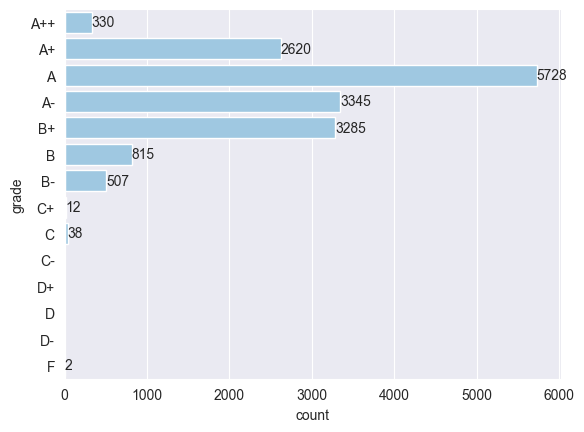

In [16]:
ax = sns.countplot(unique_consensus_df['grade'].sort_values(), color=blue)
ax.bar_label(ax.containers[0])

ax.get_figure().savefig('plots/unique_pair_grade_dist.pdf', bbox_inches='tight')

In [32]:
# Filter out F and merge C - too few samples

unique_consensus_df = unique_consensus_df[unique_consensus_df['grade'] != 'F']
unique_consensus_df['grade'] = unique_consensus_df['grade'].apply(lambda g: g[0] if g[0] == 'C' else g)
unique_consensus_df['grade'].value_counts()

grade
A      5728
A-     3345
B+     3285
A+     2620
B       815
B-      507
A++     330
C        50
Name: count, dtype: int64

In [33]:
unique_consensus_df.head()

,docstring,function,grades,grade_count,grade
hash,,,,,
-9223113457798641853,This method returns the minimum height of land...,public double getMinHeight() {\n return...,{'A': 1},1,A
-9222959580592738688,Increment the current count by one.,public void increment()\n {\n count+...,"{'A': 88, 'B+': 56, 'F': 5, 'A+': 33, 'A-': 44...",256,A
-9220909313050789122,Make the animal dead if the number of days wit...,protected void deathDueToInfection()\n {\n ...,{'A': 1},1,A
-9220844227210830767,Return true if plant is alive\n@return true if...,public boolean isActive()\n {\n retu...,{'B': 1},1,B
-9218073879879662209,Sets the food level of the organism.\n\n@param...,protected void setFoodLevel(int foodLevel){\n ...,{'A+': 1},1,A+


In [34]:
unique_consensus_df.to_csv('data/menagerie_unique_pairs_truncated.csv')

In [36]:
unique_consensus_df['grade_truncated'] = unique_consensus_df['grade'].apply(lambda g: g[0] if g is not None else None)
unique_consensus_df['grade_truncated'] = pd.Categorical(unique_consensus_df['grade_truncated'], menagerie_truncated_grades, ordered=True)
unique_consensus_df.head()

,docstring,function,grades,grade_count,grade,grade_truncated
hash,,,,,,
-9223113457798641853,This method returns the minimum height of land...,public double getMinHeight() {\n return...,{'A': 1},1,A,A
-9222959580592738688,Increment the current count by one.,public void increment()\n {\n count+...,"{'A': 88, 'B+': 56, 'F': 5, 'A+': 33, 'A-': 44...",256,A,A
-9220909313050789122,Make the animal dead if the number of days wit...,protected void deathDueToInfection()\n {\n ...,{'A': 1},1,A,A
-9220844227210830767,Return true if plant is alive\n@return true if...,public boolean isActive()\n {\n retu...,{'B': 1},1,B,B
-9218073879879662209,Sets the food level of the organism.\n\n@param...,protected void setFoodLevel(int foodLevel){\n ...,{'A+': 1},1,A+,A


[Text(0, 0, '12023'), Text(0, 0, '4607'), Text(0, 0, '50')]

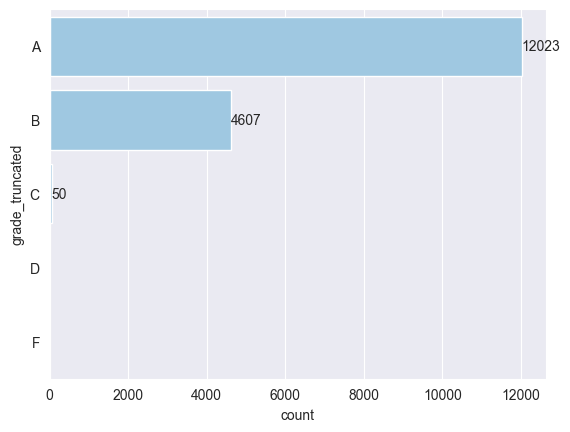

In [37]:
ax = sns.countplot(unique_consensus_df['grade_truncated'].sort_values(), color=blue)
ax.bar_label(ax.containers[0])